In [ ]:
import torch

In [ ]:
s1=torch.tensor(3)
s1
s1.item()
s1.dtype

torch.int64

In [ ]:
s2=torch.tensor([2,3,4,5])
print(s2[0].item())
print(s2)

2
tensor([2, 3, 4, 5])


In [ ]:
T_data=[[1,2,3,4],
    [3,4,5,6],
    [7,89,4,3]]

t=torch.tensor(T_data)
print(t)

tensor([[ 1,  2,  3,  4],
        [ 3,  4,  5,  6],
        [ 7, 89,  4,  3]])


In [ ]:
# Scalar Multiplication
s=2*s2
print(s)

tensor([ 4,  6,  8, 10])


https://docs.pytorch.org/docs/stable/generated/torch.matmul.html

In [ ]:
# Matrix Multiplication
tensor1 = torch.randn(3)
tensor2 = torch.randn(3)
MatMul=torch.matmul(tensor1, tensor2)
print(tensor1)
print(tensor2)
print(MatMul)

tensor([-1.1788,  0.6931,  0.0661])
tensor([ 0.5735, -1.8081,  0.0884])
tensor(-1.9234)


https://docs.pytorch.org/docs/stable/generated/torch.add.html



In [ ]:


# Matrix Addition
x=torch.tensor([1.0,4.0,3.0])
y=torch.tensor([4.0,1.0,2.0])
print(x+y)

# Method 2
print(torch.add(x,y))

tensor([5., 5., 5.])
tensor([5., 5., 5.])


https://docs.pytorch.org/docs/stable/generated/torch.reshape.html

In [ ]:
#reshaping the tensor
a=torch.tensor([2.0,3.0,7.0,5.0])
b=torch.reshape(a,(2,2))
b_3D=torch.reshape(a,(2,2,1))
print(b)
print(b_3D)

c=torch.tensor([[0,5], [1, 4],[2,8]])
d=torch.reshape(c, (-1,))
print(d)

tensor([[2., 3.],
        [7., 5.]])
tensor([[[2.],
         [3.]],

        [[7.],
         [5.]]])
tensor([0, 5, 1, 4, 2, 8])


In [ ]:
def f(x):
  return x**2+3*x+5


In [ ]:
f(3)

23

https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html

In [ ]:
a=torch.tensor(3.0,requires_grad=True)
b=f(a)
b.backward()
# d/dx (f(x))=2*x+3 -- putting x==3 gradient will be equal to 9;
print(a.grad.item())
#Functionn value
print(b.item())


9.0
23.0


**MULTIVARAIBLE GRADIENT**

In [ ]:
def f(x,y):
  return x**2+y**2+x*y

In [ ]:
x=torch.tensor(5.0,requires_grad=True)
y=torch.tensor(2.0,requires_grad=True)

f_value=f(x,y)
f_value.backward()

# 'x' gradient tells how much the output changes on changing x.
# Methamatically : d(f(x,y))/dx=2*x+y
print(x.grad.item())

# 'y' gradient tells how much the output changes on changing y.
# Methamatically : d(f(x,y))/dx=2*y+x
print(y.grad.item())

12.0
9.0


**Fashion MNIST**

In [ ]:
import torch
from torchvision import datasets,transforms
from torch.utils.data import DataLoader,random_split
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
my_transforms=transforms.Compose([
  transforms.ToTensor(),
  # transforms.Normalize((0.0,),(1.0,)) ---||-- ToTensor() does this automatically by scaling values from 0-255 to 0-1
  transforms.Lambda(lambda x: torch.flatten(x))
])

In [ ]:
full_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=my_transforms
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.08MB/s]


In [ ]:
train_size=int(0.8*len(full_data))
test_size=int(0.2*len(full_data))

traning_data,testing_data=random_split(full_data,[train_size,test_size])

In [ ]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

In [ ]:
found_classes={}
while len(found_classes)<10:
  for img,label in full_data:
    if label not in found_classes:
      found_classes[label]=img

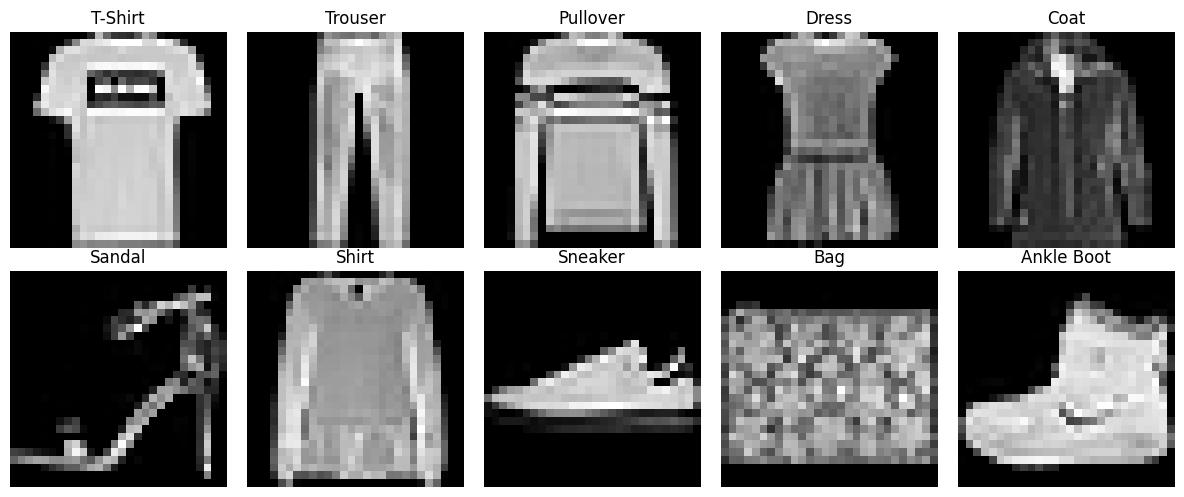

In [ ]:
fig,axes=plt.subplots(2,5,figsize=(12,5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    # Reshape the 784 vector back to 28x28 for visualization
    img_plot = found_classes[i].reshape(28, 28)
    ax.imshow(img_plot, cmap="gray")
    ax.set_title(labels_map[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# def f(x1,x2,x3):
#   return x1**2+5*x2+x3+torch.rand(1)

In [ ]:
x_train=torch.tensor([[3.0,4.0,5.0],
                [1.0,3.0,5.5],
                [2.3,6.7,8.1],
                [1.9,5.7,2.2],
                [1.1,1.5,3.4],
                [5.5,2.4,5.2],
                [4.5,1.0,2.0],
                [2.1, 1.9, 0.9],
                [3.8, 0.4, 2.7],
                [1.5, 2.5, 1.5],
                [2.9, 1.2, 3.3],
                [0.6, 0.9, 2.4]])

In [ ]:
# y_true=[]
# for example in x:
#   y_example=f(example[0],example[1],example[2])
#   y_true.append(y_example)

# y_true = torch.stack(y_true)   # convert list → tensor

# print(y_true)

**Better Approach to do the same**

In [ ]:
# function: x1**2+5*x2+x3  -- d(f(x))/dx1=2*x1  &  d(f(x))/dx2=5   & d(f(x))/dx3=1
def f(x):
  return x[:,0:1]**2+5*x[:,1:2]+x[:,2:3]+torch.rand(x.size(0),1)

y_true=f(x_train)
print(y_true)

tensor([[34.6946],
        [22.0670],
        [47.4987],
        [35.3000],
        [13.0319],
        [48.0583],
        [27.7702],
        [15.4698],
        [19.9138],
        [16.6394],
        [17.9582],
        [ 8.1379]])


In [ ]:
# since we have three input features we need a weight matrix of size (3x1)
W=torch.rand(3,1)
b=torch.rand(1,1)
print(W)
print(b)

tensor([[0.4594],
        [0.5456],
        [0.5141]])
tensor([[0.2245]])


In [ ]:
y_pred=x_train@W+b
loss=((y_pred-y_true)**2).mean()
print(loss.item())

556.8974609375


In [ ]:
for k in range(100):
  y_pred=x_train @ W+b
  loss=((y_pred-y_true)**2).mean()
  # Differentiation of loss w.r.t weights --- means how does the loss change or
  # how much loss changes when weights are slightly changed.
  # d(loss)/dw= 2*(y_pred-y_true)*(d(x@w/dx))=2*error*x
  n=x_train.size(0)

  error=y_pred-y_true

  dW=(2/n)*(x_train.T @ error)
  db=(2/n)*error.sum()

  # upgrade weights and biases
  lr=0.01
  W=W-lr*dW
  b=b-lr*db

  if (k+1)%10==0 :
    print(loss.item())

20.288681030273438
14.743054389953613
11.915474891662598
10.310598373413086
9.323271751403809
8.672924995422363
8.215577125549316
7.872561931610107
7.599399089813232
7.37041711807251


In [ ]:
print(W,b)

tensor([[4.7688],
        [3.9191],
        [1.2000]]) tensor([[-0.2378]])
